In [11]:
import pandas as pd # Manipulação de dados
import numpy as np # Cálculos matemáticos
import yfinance as yf #Importação dos dados
import matplotlib.pyplot as plt #Gráficos
import plotly.express as px #Gráficos interativos
import plotly.graph_objects as go #Gráfico interativos
import seaborn as sns #Estatísticas e gráficos
from scipy import stats #Estatísticas

#Importação dos dados

tickers = ['PETR4.SA', 'ITUB4.SA', 'VALE3.SA']
dataset = yf.download(tickers, start='2025-01-01', end='2026-03-10')['Close']
dataset

C:\Users\henri\AppData\Local\Temp\ipykernel_23664\1621747078.py:13: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


Ticker,ITUB4.SA,PETR4.SA,VALE3.SA
Date,,,
2025-01-02,23.522552,32.033466,47.932838
2025-01-03,22.945457,31.693705,47.040447
2025-01-06,23.976542,31.545607,46.439632
2025-01-07,24.238153,32.216412,45.989017
2025-01-08,23.845724,31.955059,45.547237
...,...,...,...
2026-03-03,43.959473,39.729538,84.480003
2026-03-04,44.583500,39.292950,84.089996
2026-03-05,43.097717,39.477283,81.290001


In [12]:
plt.figure(figsize=(18,6))

fig_precos = px.line(dataset, x=dataset.index, y=tickers,
                     title='Preços de Fechamento ao Longo do Tempo',
                     labels={'value': 'Preço (R$)', 'Date': 'Data'})
fig_precos.show()

<Figure size 1800x600 with 0 Axes>

,Média,Mediana,Variância,Desvio-Padrão
Ticker,,,,
ITUB4.SA,33.725536,33.519135,33.781576,5.812192
PETR4.SA,30.506481,29.707401,7.948671,2.819339
VALE3.SA,57.732865,52.187904,154.910082,12.446288


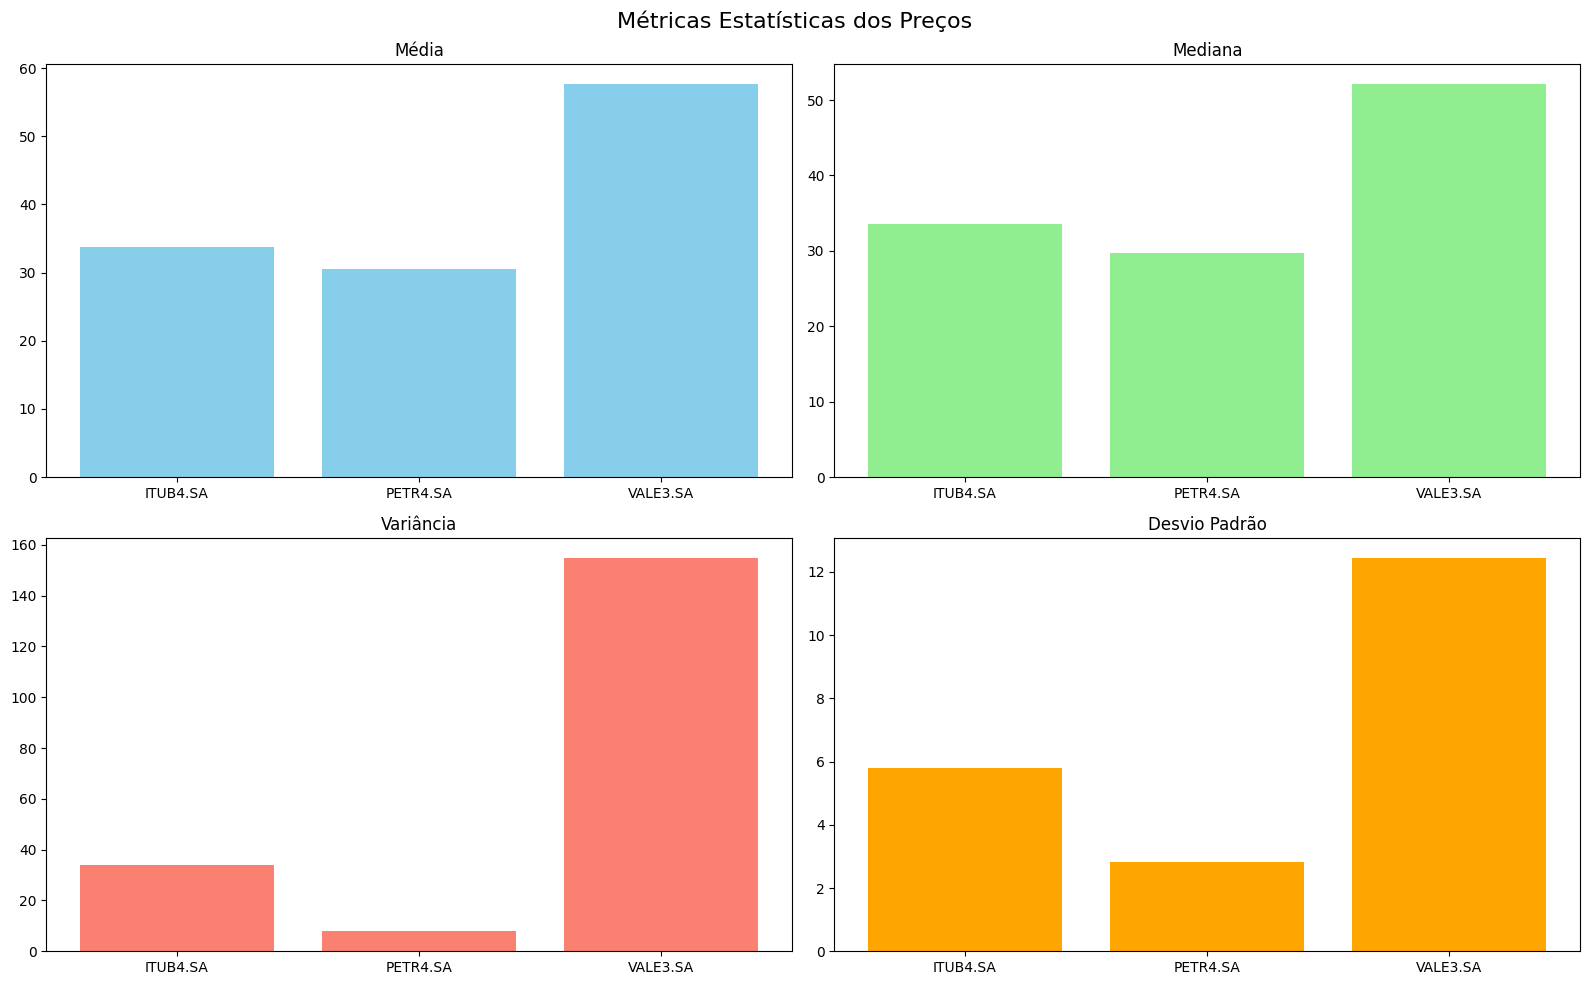

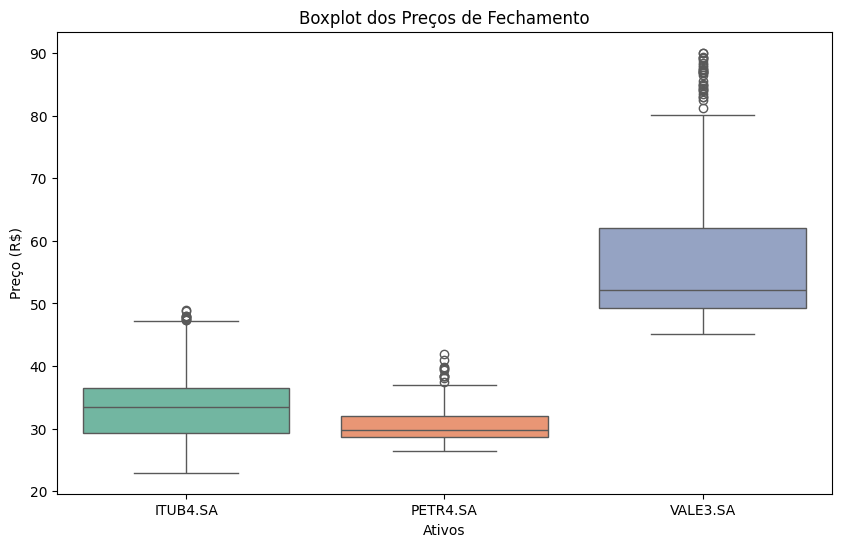

In [13]:
# --- Análise estatística dos preços --- 


df_prices = dataset.copy()
stats_df_prices = pd.DataFrame(index=df_prices.columns)
stats_df_prices['Média'] = df_prices.mean()
stats_df_prices['Mediana'] = df_prices.median() 
stats_df_prices['Variância'] = df_prices.var()
stats_df_prices['Desvio-Padrão'] = df_prices.std()

display(stats_df_prices)

# --- Plotagem das análises estatísticas --- 

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Métricas Estatísticas dos Preços', fontsize=16) 

# --- Média, Mediana, Variância e Desvio Padrão ---

axes[0, 0].bar(stats_df_prices.index, stats_df_prices['Média'], color='skyblue')
axes[0, 0].set_title('Média')

axes[0, 1].bar(stats_df_prices.index, stats_df_prices['Mediana'], color='lightgreen')
axes[0, 1].set_title('Mediana')

axes[1, 0].bar(stats_df_prices.index, stats_df_prices['Variância'], color='salmon')
axes[1, 0].set_title('Variância')

axes[1, 1].bar(stats_df_prices.index, stats_df_prices['Desvio-Padrão'], color='orange')
axes[1, 1].set_title('Desvio Padrão')

plt.tight_layout()
plt.show()

# --- Boxplot para análise de outliers --- 

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_prices, palette="Set2")
plt.title('Boxplot dos Preços de Fechamento')
plt.ylabel('Preço (R$)')
plt.xlabel('Ativos')
plt.show()


In [14]:
# Calculando os retornos logarítmicos
# Os retornos são variáveis estacionárias e representam a verdadeira variação percentual contínua 
# de um papel ao longo do tempo

log_returns = np.log(dataset / dataset.shift(1))
log_returns = log_returns.dropna().fillna(0)
log_returns

Ticker,ITUB4.SA,PETR4.SA,VALE3.SA
Date,,,
2025-01-03,-0.024840,-0.010663,-0.018793
2025-01-06,0.043956,-0.004684,-0.012855
2025-01-07,0.010852,0.021042,-0.009751
2025-01-08,-0.016323,-0.008145,-0.009653
2025-01-09,0.002578,0.004352,-0.006227
...,...,...,...
2026-03-03,-0.034112,-0.004386,-0.042639
2026-03-04,0.014096,-0.011050,-0.004627
2026-03-05,-0.033894,0.004680,-0.033865


Plotagem das análises estatísticas

--- Estatísticas Descritivas dos Retornos Logarítmicos ---


,Média,Mediana,Moda,Desvio Padrão,Variância,Assimetria (Skewness),Curtose (Kurtosis)
Ticker,,,,,,,
ITUB4.SA,0.002032,0.001968,0.000000,0.013945,0.000194,-0.006454,1.273749
PETR4.SA,0.000911,0.001575,0.000000,0.014931,0.000223,-0.496184,2.714563
VALE3.SA,0.001711,0.001299,-0.056311,0.015423,0.000238,-0.082752,1.681180



--- Matriz de Covariância ---


Ticker,ITUB4.SA,PETR4.SA,VALE3.SA
Ticker,,,
ITUB4.SA,0.000194,0.000053,0.000062
PETR4.SA,0.000053,0.000223,0.000051
VALE3.SA,0.000062,0.000051,0.000238


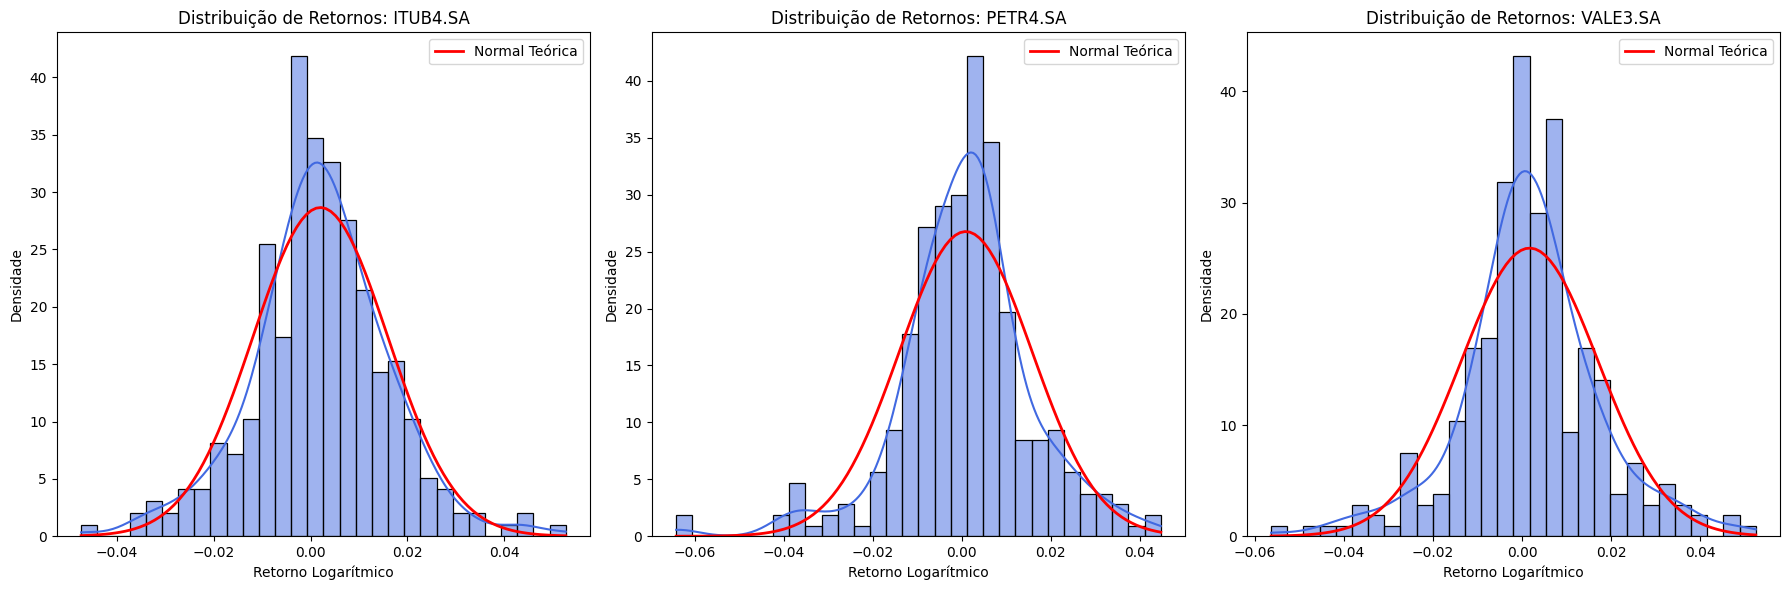

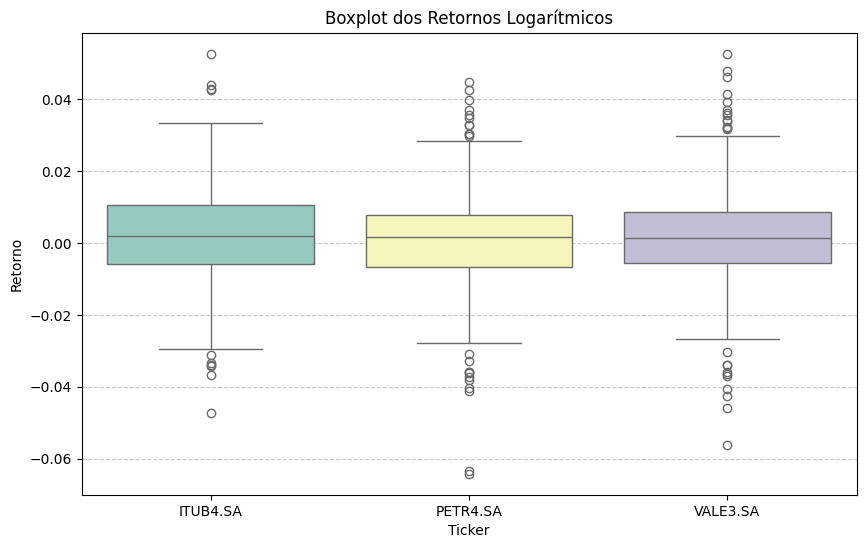

In [15]:
# --- Plotagem das variáveis estatísticas descritivas ----

plt.figure(figsize=(18,6))

# Cálculo das variáveis estatísticas descritivas 
stats_df = pd.DataFrame(index=log_returns.columns)
stats_df['Média'] = log_returns.mean()
stats_df['Mediana'] = log_returns.median()
stats_df['Moda'] = log_returns.apply(lambda x: x.mode().iloc[0])
stats_df['Desvio Padrão'] = log_returns.std()
stats_df['Variância'] = log_returns.var()
stats_df['Assimetria (Skewness)'] = log_returns.skew()
stats_df['Curtose (Kurtosis)'] = log_returns.kurt()

print("--- Estatísticas Descritivas dos Retornos Logarítmicos ---")
display(stats_df)

#Covariância dos ativos:
cov_matrix = log_returns.cov()
print("\n--- Matriz de Covariância ---")
display(cov_matrix)

#Gráficamente...

for i, ticker in enumerate(log_returns.columns):
    plt.subplot(1, 3, i + 1)
    sns.histplot(log_returns[ticker], kde=True, color='royalblue', bins=30, stat="density")
    
    # Adicionando uma linha da Distribuição Normal Teórica para comparação
    mu, std = stats.norm.fit(log_returns[ticker])
    x = np.linspace(log_returns[ticker].min(), log_returns[ticker].max(), 100)
    p = stats.norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth=2, label='Normal Teórica')
    
    plt.title(f'Distribuição de Retornos: {ticker}')
    plt.xlabel('Retorno Logarítmico')
    plt.ylabel('Densidade')
    plt.legend()

plt.tight_layout()
plt.show()

# 4. Plotagem de Boxplot
# Útil para visualizar a mediana, quartis e a presença de outliers (pontos extremos)
plt.figure(figsize=(10, 6))
sns.boxplot(data=log_returns, palette="Set3")
plt.title('Boxplot dos Retornos Logarítmicos')
plt.ylabel('Retorno')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


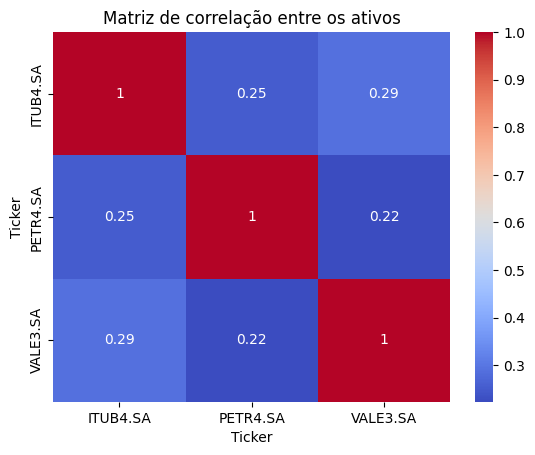

In [16]:
# --- Análise da correlação entre os papéis --- 
correlation_matrix = log_returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Matriz de correlação entre os ativos")
plt.show()

#Confirmação da importância da diversificação de portfólio


In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

rolling_corr_petr4_vale3 = log_returns['PETR4.SA'].rolling(window=60).corr(log_returns['VALE3.SA'])
rolling_corr_itub4_petr4 = log_returns['ITUB4.SA'].rolling(window=60).corr(log_returns['PETR4.SA'])
rolling_corr_vale3_itub4 = log_returns['VALE3.SA'].rolling(window=60).corr(log_returns['ITUB4.SA'])

# Plotting process
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=rolling_corr_petr4_vale3.index,
    y=rolling_corr_petr4_vale3,
    name='PETR4.SA vs VALE3.SA',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=rolling_corr_itub4_petr4.index,
    y=rolling_corr_itub4_petr4,
    name='ITUB4.SA vs PETR4.SA',
    line=dict(color='red')
))

fig.add_trace(go.Scatter(
    x=rolling_corr_vale3_itub4.index,
    y=rolling_corr_vale3_itub4,
    name='VALE3.SA vs ITUB4.SA',
    line=dict(color='green')
))

fig.add_hline(y=0, line_dash='dash')

fig.update_layout(
    title='Série Temporal da Correlação Móvel entre os ativos (2025-2026)',
    xaxis_title='Data',
    yaxis_title='Correlação Móvel de Pearson',
    yaxis_range=[-1, 1],
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=600
)
fig.show()

In [18]:
# Indicadores de sucesso (retorno > 0)
import itertools
up_moves = (log_returns > 0).astype(int)

# Probabilidades de sucesso (p)
p = up_moves.mean()
print(f"Probabilidades de retorno positivo:\n{p}\n")

# Soma observada (X = número de ativos que sobem no dia)
up_moves['S_obs'] = up_moves.sum(axis=1)
freq_obs = up_moves['S_obs'].value_counts(normalize=True).sort_index()

# Distribuição Teórica (Independência)
# Usando o produto cartesiano para gerar os 8 estados (0,0,0 até 1,1,1)
probs_p = p.values
states = list(itertools.product([0, 1], repeat=3))
teorica = {0:0, 1:0, 2:0, 3:0}

for s in states:
    # Probabilidade do estado: P(X1=s1)*P(X2=s2)*P(X3=s3)
    prob_estado = 1
    for i in range(3):
        prob_estado *= (probs_p[i]**s[i]) * ((1-probs_p[i])**(1-s[i]))
    teorica[sum(s)] += prob_estado

# Comparação
df_comp = pd.DataFrame({
    'Soma': [0,1,2,3],
    'Empírica': [freq_obs.get(i, 0) for i in range(4)],
    'Teórica': [teorica[i] for i in range(4)]
}).melt(id_vars='Soma', var_name='Tipo', value_name='Probabilidade')

fig_bernoulli = px.bar(df_comp, x='Soma', y='Probabilidade', color='Tipo', barmode='group',
                       title='Distribuição do Número de Ativos com Retorno Positivo')
fig_bernoulli.show()

Probabilidades de retorno positivo:
Ticker
ITUB4.SA    0.568027
PETR4.SA    0.544218
VALE3.SA    0.540816
dtype: float64



--------------------------------------------------------------------------------
RESULTADOS DA FRONTEIRA EFICIENTE DE MARKOWITZ:
Retorno Esperado (Anual): 46.72%
Volatilidade/Risco (Anual): 18.05%
Índice de Sharpe Máximo:  2.59

Alocação de Pesos Sugerida (Max Sharpe):
  -> PETR4.SA: 60.93%
  -> ITUB4.SA: 6.56%
  -> VALE3.SA: 32.51%
--------------------------------------------------------------------------------


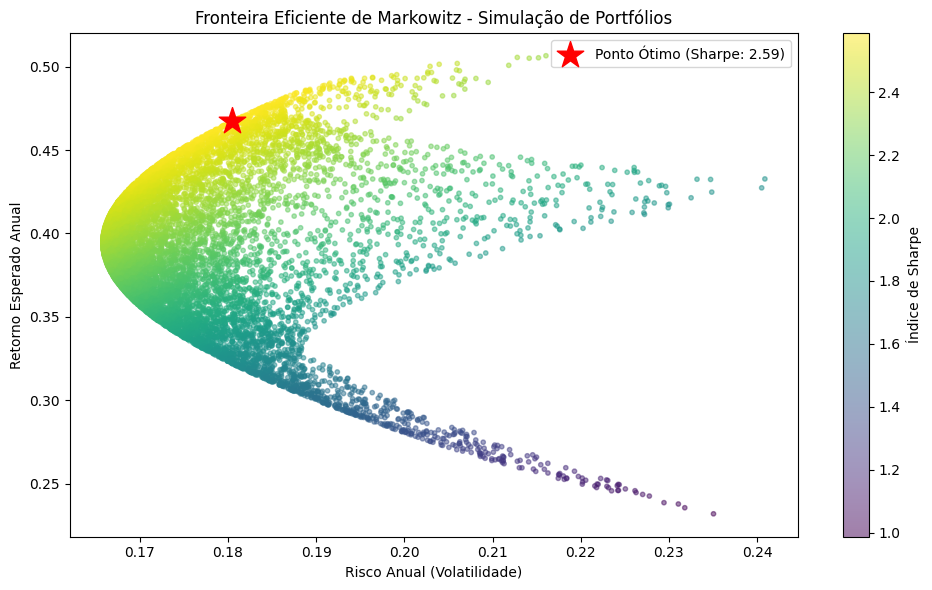

In [19]:
# 1. Preparação das variáveis (Cálculo de Retorno Médio e Covariância)
mean_daily = log_returns.mean()
cov_daily = log_returns.cov()

# Número de portfólios a serem simulados (Monte Carlo)
n_portfolios = 10000

# Arrays para armazenar resultados (Retorno, Volatilidade e Sharpe)
results = np.zeros((3, n_portfolios))
weights_record = []

# Taxa livre de risco (assumida como 0 ou você pode inserir a taxa Selic diária)
taxa_livre_risco = 0.0

for i in range(n_portfolios):
    # Gerando pesos aleatórios
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Retorno e risco do portfólio anualizados (multiplicando por 252 dias úteis)
    portfolio_return = np.sum(mean_daily * weights) * 252
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_daily, weights))) * np.sqrt(252)
    
    # Salvando resultados
    results[0, i] = portfolio_return
    results[1, i] = portfolio_std_dev
    results[2, i] = (portfolio_return - taxa_livre_risco) / portfolio_std_dev

# 2. Identificando o portfólio com o Maior Índice de Sharpe
max_sharpe_idx = np.argmax(results[2])
max_sharpe_retorno = results[0, max_sharpe_idx]
max_sharpe_volatilidade = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]

# --- AJUSTE 2: Resgatando os pesos ótimos da fronteira eficiente ---
pesos_otimos = weights_record[max_sharpe_idx]

# --- AJUSTE 1: Cuspindo a formatação do Sharpe e dos Pesos Corretamente ---
print('-' * 80)
print('RESULTADOS DA FRONTEIRA EFICIENTE DE MARKOWITZ:')
print(f"Retorno Esperado (Anual): {max_sharpe_retorno:.2%}")
print(f"Volatilidade/Risco (Anual): {max_sharpe_volatilidade:.2%}")
print(f"Índice de Sharpe Máximo:  {max_sharpe_ratio:.2f}") # Formatação travada em 2 casas decimais

print('\nAlocação de Pesos Sugerida (Max Sharpe):')
for ticker, peso in zip(tickers, pesos_otimos):
    print(f"  -> {ticker}: {peso:.2%}")
print('-' * 80)

# Atualizando o dicionário de alocação que será usado nas simulações finais do seu notebook
portfolio_allocations = {
    'Max Sharpe (Fronteira Eficiente)': pesos_otimos,
    'Pesos Iguais (Ingênua)': np.array([1/len(tickers)] * len(tickers))
}

# 3. Visualizando o Gráfico da Fronteira Eficiente
plt.figure(figsize=(10, 6))
# Plota todos os portfólios simulados
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Índice de Sharpe')

# Destacando a estrela vermelha no portfólio de Maior Sharpe (Ponto Ótimo)
plt.scatter(max_sharpe_volatilidade, max_sharpe_retorno, marker='*', color='red', s=400, 
            label=f'Ponto Ótimo (Sharpe: {max_sharpe_ratio:.2f})')

plt.title('Fronteira Eficiente de Markowitz - Simulação de Portfólios')
plt.xlabel('Risco Anual (Volatilidade)')
plt.ylabel('Retorno Esperado Anual')
plt.legend(labelspacing=0.8)
plt.tight_layout()
plt.show()

PROJEÇÃO MONTE CARLO: PORTFÓLIO MAX SHARPE (1 ANO | 100000 CENÁRIOS)
Investimento Inicial:      R$ 1,000,000.00
Valor Esperado (Média):    R$ 1,594,812.20  (Retorno de 59.48%)
Cenário Base (Mediana):    R$ 1,567,597.30
Pior Cenário (5% - VaR):   R$ 1,165,049.44  (Risco Máximo de Perda em 95% dos casos)
Melhor Cenário (95%):      R$ 2,112,046.91


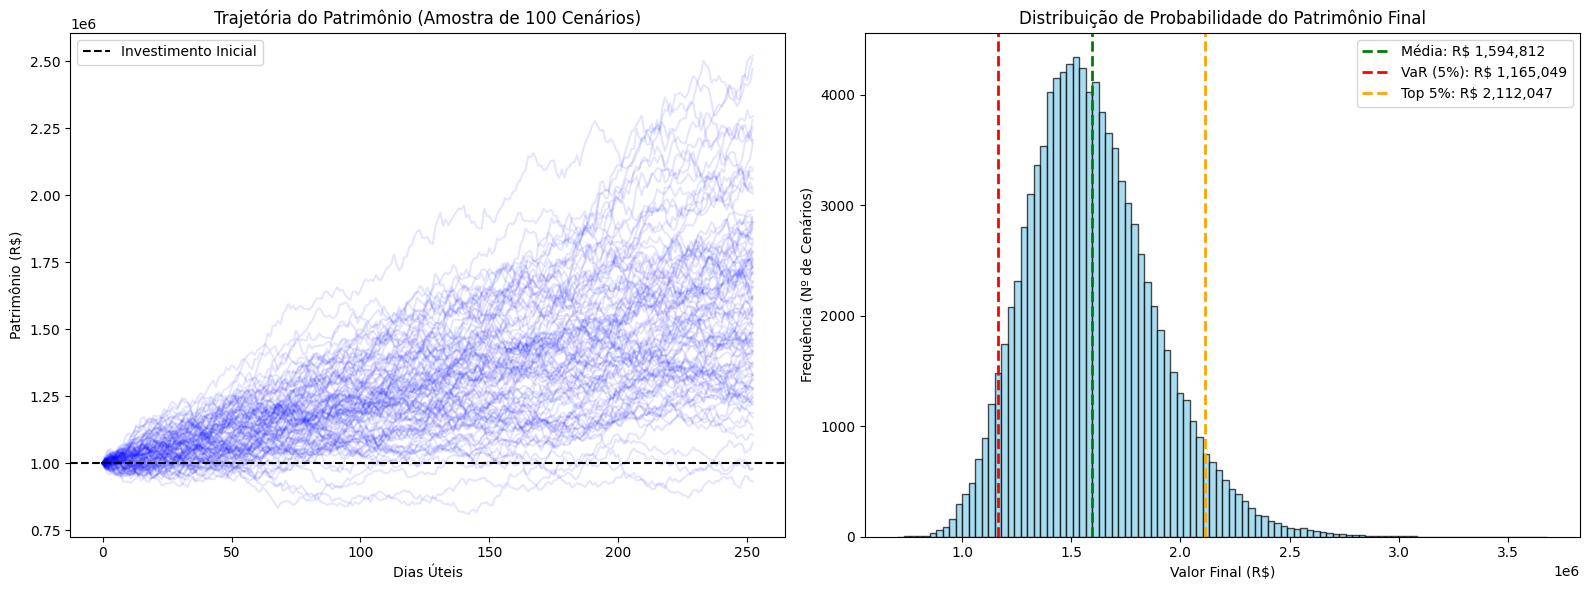

In [20]:
# --- PARÂMETROS DA SIMULAÇÃO ---
investimento_inicial = 1_000_000  # Exemplo: R$ 1.000.000 investidos
dias_projetados = 252            # 1 ano de pregões úteis
n_cenarios = 100_000               # Número de simulações (Caminhos)

# 1. Calculando o Retorno Esperado (mu) e a Volatilidade (sigma) DIÁRIOS do Portfólio Ótimo
# Usamos os 'pesos_otimos' gerados na célula de Markowitz
mu_p = np.dot(pesos_otimos, mean_daily)
sigma_p = np.sqrt(np.dot(pesos_otimos.T, np.dot(cov_daily, pesos_otimos)))

# 2. Gerando a Matriz de Choques Aleatórios (Z ~ N(0,1))
# Uma matriz de 252 dias por 10.000 cenários
Z = np.random.standard_normal((dias_projetados, n_cenarios))

# 3. Aplicando o Movimento Browniano Geométrico (GBM)
# Fórmula: Retorno = exp((mu - 0.5 * sigma^2) + sigma * Z)
retornos_simulados = np.exp((mu_p - 0.5 * sigma_p**2) + sigma_p * Z)

# 4. Construindo a trajetória do capital ao longo do tempo (Caminhos de Preço)
# np.vstack adiciona o dia 0 (investimento inicial) no topo da matriz
matriz_caminhos = np.vstack([np.ones(n_cenarios), np.cumprod(retornos_simulados, axis=0)])
evolucao_patrimonio = investimento_inicial * matriz_caminhos

# 5. Extraindo os resultados finais (o valor no dia 252)
valores_finais = evolucao_patrimonio[-1, :]

valor_esperado = np.mean(valores_finais)
pior_cenario_5 = np.percentile(valores_finais, 5)   # Value at Risk (VaR) de 95%
melhor_cenario_95 = np.percentile(valores_finais, 95)
mediana_cenario = np.median(valores_finais)

# --- SAÍDA DE DADOS FORMATADA ---
print('=' * 80)
print(f'PROJEÇÃO MONTE CARLO: PORTFÓLIO MAX SHARPE (1 ANO | {n_cenarios} CENÁRIOS)')
print('=' * 80)
print(f"Investimento Inicial:      R$ {investimento_inicial:,.2f}")
print(f"Valor Esperado (Média):    R$ {valor_esperado:,.2f}  (Retorno de {(valor_esperado/investimento_inicial - 1):.2%})")
print(f"Cenário Base (Mediana):    R$ {mediana_cenario:,.2f}")
print(f"Pior Cenário (5% - VaR):   R$ {pior_cenario_5:,.2f}  (Risco Máximo de Perda em 95% dos casos)")
print(f"Melhor Cenário (95%):      R$ {melhor_cenario_95:,.2f}")
print('=' * 80)

# --- VISUALIZAÇÃO GRÁFICA ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: A trajetória de 100 cenários aleatórios (para não poluir visualmente)
axes[0].plot(evolucao_patrimonio[:, :100], alpha=0.1, color='blue')
axes[0].axhline(y=investimento_inicial, color='black', linestyle='--', label='Investimento Inicial')
axes[0].set_title(f'Trajetória do Patrimônio (Amostra de 100 Cenários)')
axes[0].set_xlabel('Dias Úteis')
axes[0].set_ylabel('Patrimônio (R$)')
axes[0].legend()

# Gráfico 2: Distribuição dos Valores Finais (Histograma com VaR)
axes[1].hist(valores_finais, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(valor_esperado, color='green', linestyle='dashed', linewidth=2, label=f'Média: R$ {valor_esperado:,.0f}')
axes[1].axvline(pior_cenario_5, color='red', linestyle='dashed', linewidth=2, label=f'VaR (5%): R$ {pior_cenario_5:,.0f}')
axes[1].axvline(melhor_cenario_95, color='orange', linestyle='dashed', linewidth=2, label=f'Top 5%: R$ {melhor_cenario_95:,.0f}')

axes[1].set_title('Distribuição de Probabilidade do Patrimônio Final')
axes[1].set_xlabel('Valor Final (R$)')
axes[1].set_ylabel('Frequência (Nº de Cenários)')
axes[1].legend()

plt.tight_layout()
plt.show()
